# Architecture of filters

So, the english is not very good, I will improve that

In [388]:
import itertools

import sympy as sy
import numpy as np

from sympy import Matrix
from scipy.linalg import circulant
from sympy.physics.quantum import TensorProduct
from sympy.matrices.dense import matrix_multiply_elementwise

In [389]:
import fitz

from utils import plot_pdf, plot_pdf2col, symmetrical_cyclic_convolution, conv_circ_fft

In [390]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [391]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

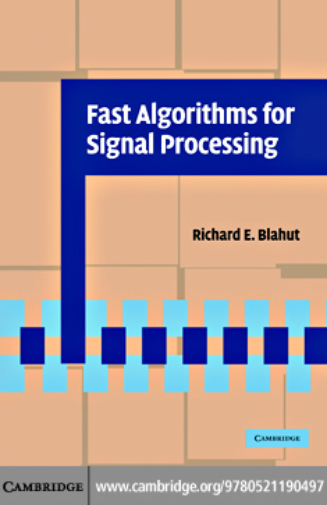

In [392]:
plot_pdf(doc[0], dpi=100)

## Polynomials

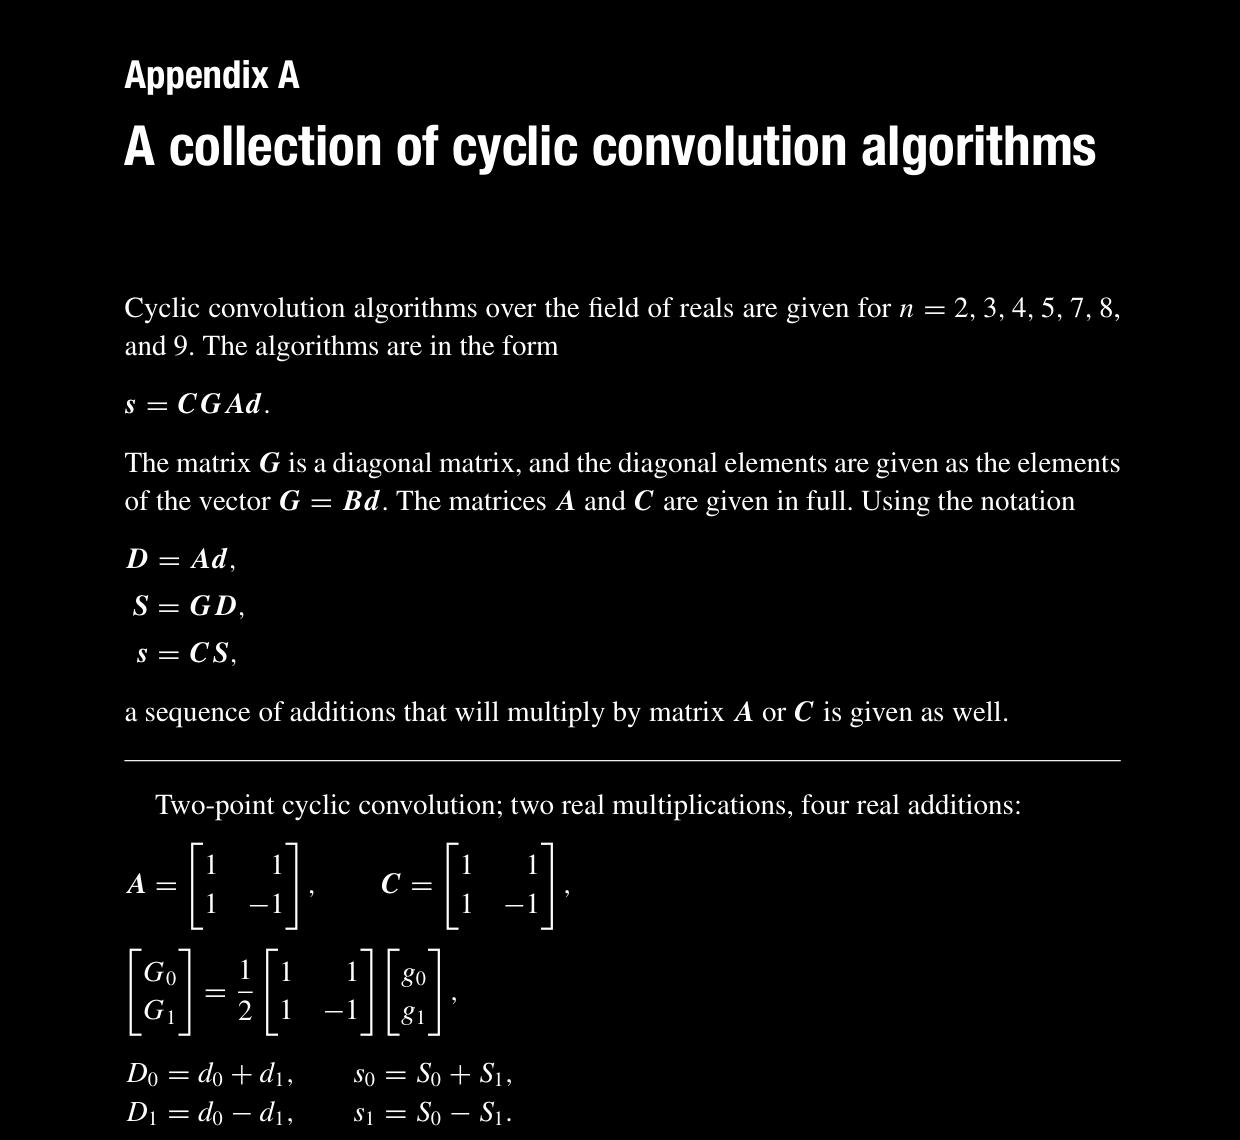

In [393]:
plot_pdf(doc[442], [0.1, .7])

Size of vectors

In [394]:
v_size = 2

Example of vectors for the convolution

In [395]:
d_values = list(range(1, v_size+1))
g_values = list(range(1, v_size+1))
print(d_values, g_values)

[1, 2] [1, 2]


Polynomial degree

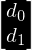

In [396]:
d0s = Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(v_size))))
d0s

In [397]:
g0s = Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(v_size))))
g0s

In [398]:
t0s = Matrix(sy.symbols(" ".join(f"t_{i}"for i in range(v_size))))
t0s

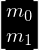

In [399]:
m0s = Matrix(sy.symbols(" ".join(f"m_{i}"for i in range(v_size))))
m0s

In [400]:
s0s = Matrix(sy.symbols(" ".join(f"s_{i}"for i in range(v_size))))
s0s

Just defining values of matrices (acho que não foi winograd que definiu a matriz abaixo, acho q foi agarwal e burrus)

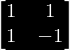

In [401]:
win = Matrix([[1, 1], [1, -1]])
win

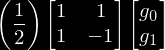

In [402]:
sy.MatMul(sy.Rational(1, 2), win, g0)

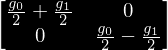

In [403]:
bg0s = sy.diag(*(win*g0*1/2).tolist())
bg0s

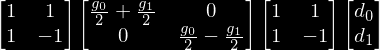

In [404]:
sy.MatMul(win, bg0s, win, d0)

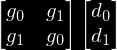

In [405]:
sy.MatMul(win * bg0s * win, d0)

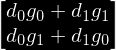

In [406]:
sy.MatMul(win, bg0s, win, d0, evaluate=True)

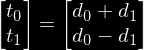

In [407]:
t0 = sy.Eq(t0s, win * d0)
t0

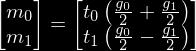

In [408]:
m0 = sy.Eq(m0s, bg0s*t0.args[0])
m0

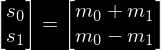

In [409]:
s0 = sy.Eq(s0s, win*m0.args[0])
s0

# Convolução circular 4x4

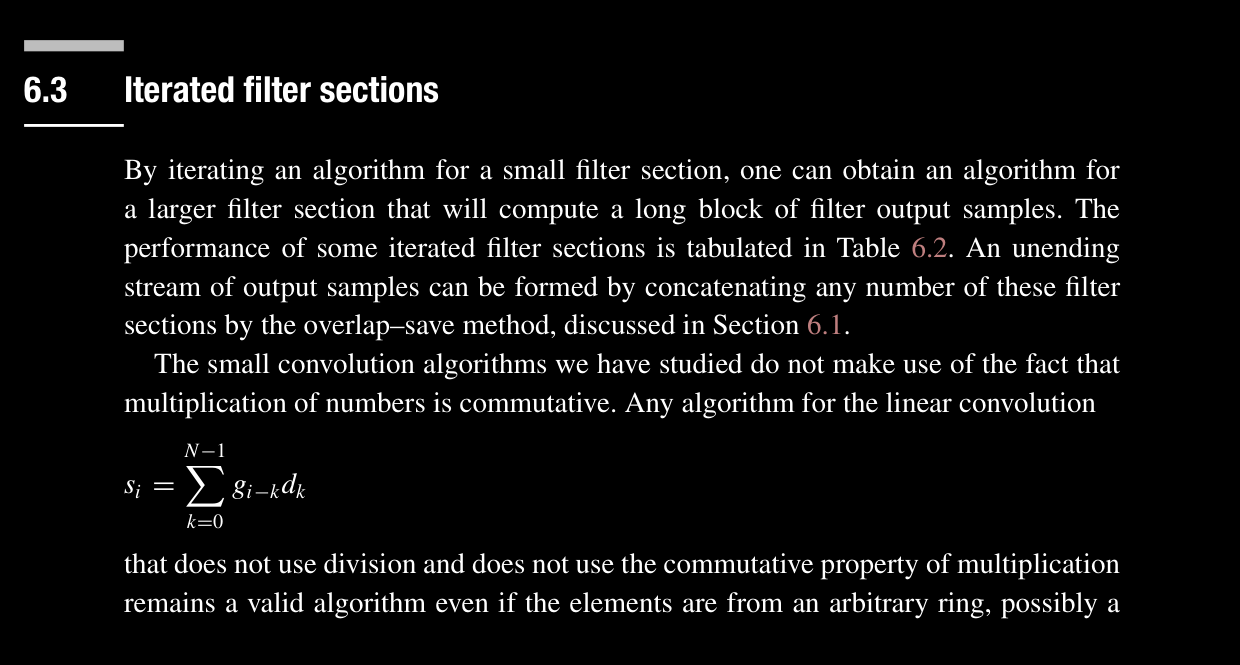

In [410]:
plot_pdf(doc[217], [.6, .95])

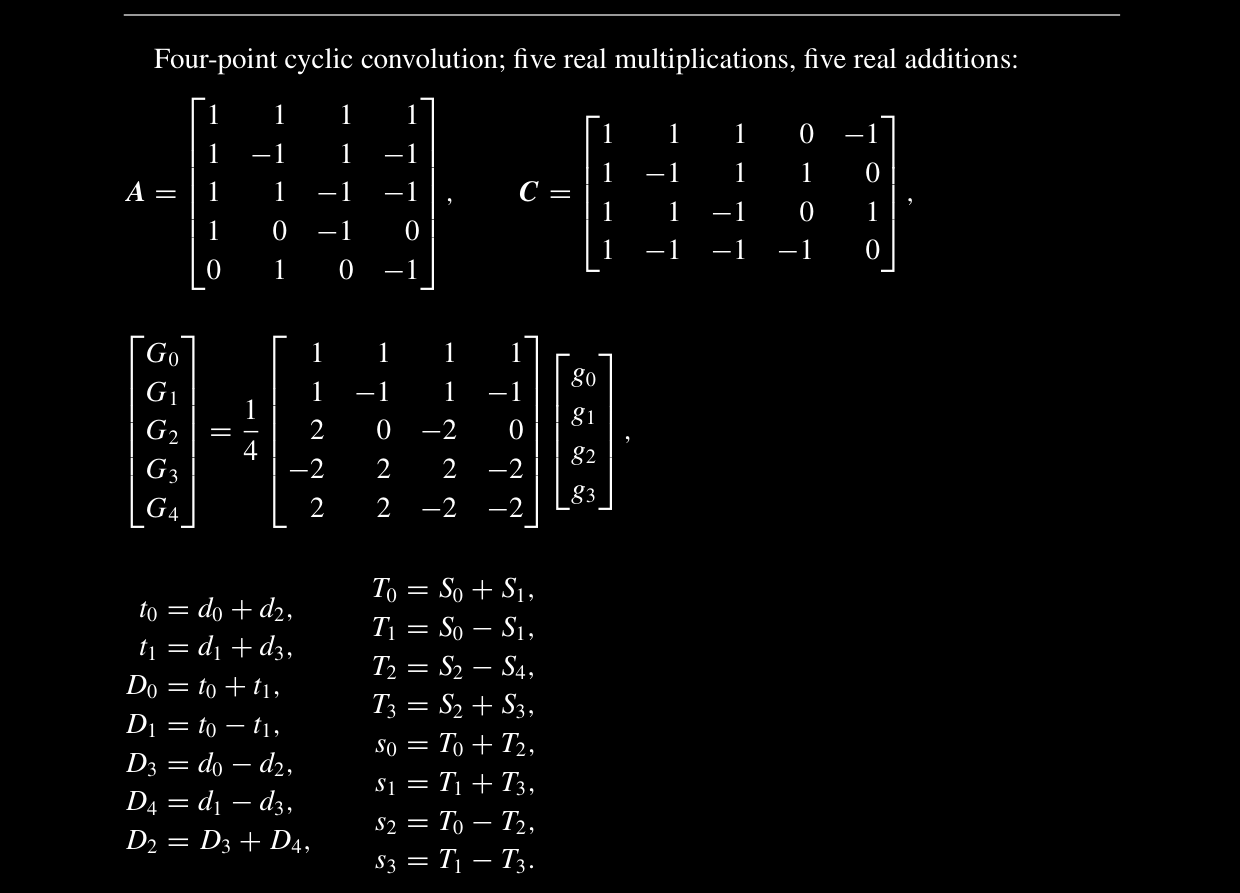

In [411]:
plot_pdf(doc[443], [0.2, .67])

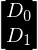

In [412]:
dd1s = sy.Matrix(sy.symbols(" ".join(f"D_{i}"for i in range(2))))
dd1s

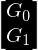

In [413]:
gg1s = sy.Matrix(sy.symbols(" ".join(f"G_{i}"for i in range(2))))
gg1s

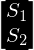

In [414]:
ss1s = sy.Matrix(sy.symbols(" ".join(f"S_{i}"for i in range(1, 3))))
ss1s

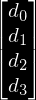

In [415]:
d1s = Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(v_size*2))))
d1s

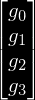

In [416]:
g1s = Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(v_size*2))))
g1s

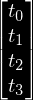

In [417]:
t1s = Matrix(sy.symbols(" ".join(f"t_{i}"for i in range(v_size*2))))
t1s

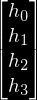

In [418]:
h1s = Matrix(sy.symbols(" ".join(f"h_{i}"for i in range(v_size*2))))
h1s

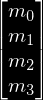

In [419]:
m1s = Matrix(sy.symbols(" ".join(f"m_{i}"for i in range(v_size*2))))
m1s

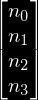

In [420]:
n1s = Matrix(sy.symbols(" ".join(f"n_{i}"for i in range(v_size*2))))
n1s

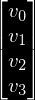

In [421]:
v1s = Matrix(sy.symbols(" ".join(f"v_{i}"for i in range(v_size*2))))
v1s

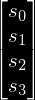

In [422]:
s1s = Matrix(sy.symbols(" ".join(f"s_{i}"for i in range(4))))
s1s

In [423]:
iis = sy.symbols('I')
iis

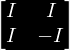

In [424]:
win_iis = Matrix([
    [iis, iis], 
    [iis, -iis]
])
win_iis

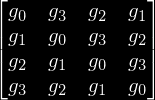

In [425]:
cc1s = sy.Matrix(circulant(g1s))
cc1s

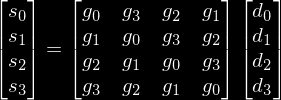

In [426]:
sy.Eq(s1s, sy.MatMul(cc1s, d1s),  evaluate=False)

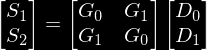

In [427]:
sy.Eq(ss1s, sy.MatMul(Matrix([[gg1s[0], gg1s[1]], [gg1s[1], gg1s[0]]]), dd1s),  evaluate=False)

In [428]:
g1ms = [
    Matrix([
        [g1s[0], g1s[3]],
        [g1s[1], g1s[0]]
    ]),
    Matrix([
        [g1s[2], g1s[1]],
        [g1s[3], g1s[2]]
    ])
]

In [429]:
d1ms = [
    Matrix([d1s[0], d1s[1]]),
    Matrix([d1s[2], d1s[3]])
]

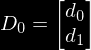

In [430]:
sy.Eq(dd1s[0], d1m[0], evaluate=False)

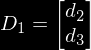

In [431]:
sy.Eq(dd1s[1], d1m[1], evaluate=False)

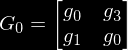

In [432]:
sy.Eq(gg1s[0], g1m[0], evaluate=False)

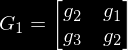

In [433]:
sy.Eq(gg1s[1], g1m[1], evaluate=False)

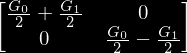

In [434]:
gg1m = sy.diag(*[
    gg1[0] + gg1[1], 
    gg1[0] - gg1[1]
])* 1/2
gg1m

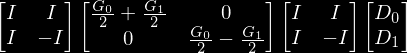

In [435]:
sy.MatMul(win_iis, gg1ms, win_iis, dd1s)

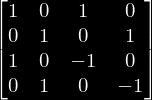

In [436]:
win1 = TensorProduct(win, sy.eye(2))
win1

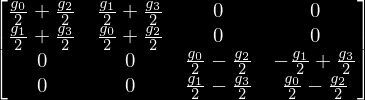

In [437]:
bg1s = sy.diag(*[
    g1m[0] + g1m[1], 
    g1m[0] - g1m[1]
])* 1/2
bg1s

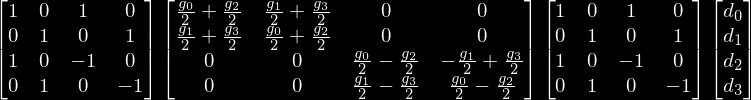

In [438]:
sy.MatMul(win1, bg1, win1, d1)

In [439]:
bg1t = Matrix([
    Matrix(g1m[0][:2]) + Matrix(g1m[1][:2]), 
    Matrix(g1m[0][:2]) - Matrix(g1m[1][:2])
])* 1/2

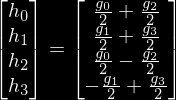

In [440]:
h1 = sy.Eq(h1s, bg1t)
h1

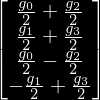

In [441]:
h1b = bg1t
h1b

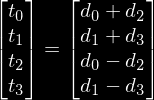

In [442]:
t1 = sy.Eq(t1s, win1 * d1)
t1

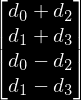

In [443]:
t1b = win1 * d1
t1b

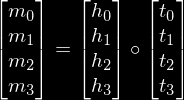

In [444]:
m1 = sy.Eq(m1s, sy.HadamardProduct(h1.args[0], t1.args[0]))
m1

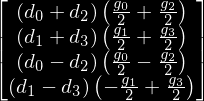

In [445]:
m1b = sy.hadamard_product(h1b, t1b)
m1b

In [446]:
sh1b = Matrix([
    [1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0],
    [0, 1, 0, 0], [1, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0],
    [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, -1],
    [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0],
])

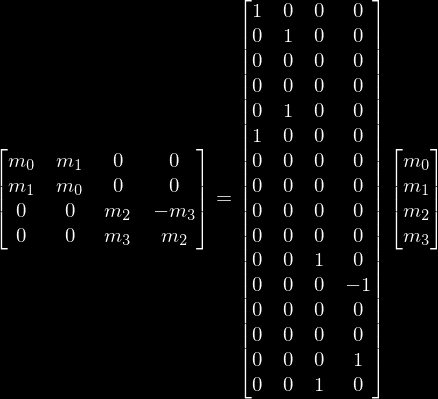

In [447]:
n1b = sy.Eq((sh1b * m1s).reshape(4,4), sy.MatMul(sh1b, m1s), evaluate=False)
n1b

In [448]:
sh1 = Matrix([
    [1, 1, 0, 0],
    [1, 1, 0, 0],
    [0, 0, 1, -1],
    [0, 0, 1, 1],
])

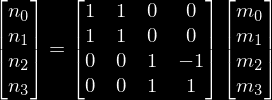

In [449]:
sy.Eq(n1s, sy.MatMul(sh1, m1.args[0]), evaluate=False)

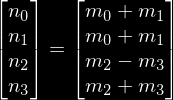

In [450]:
n1 = sy.Eq(n1s, sh1 * m1.args[0])
n1

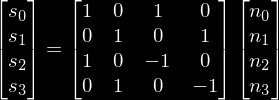

In [451]:
s1 = sy.Eq(s1s, sy.MatMul(win1, n1.args[0]), evaluate=False)
s1

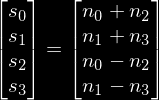

In [452]:
s1 = sy.Eq(s1s, win1 * n1.args[0])
s1

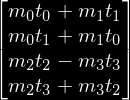

In [453]:
n1b.args[0] * t1s

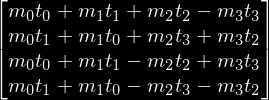

In [454]:
win1 * n1b.args[0] * t1.args[0]

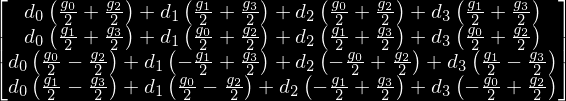

In [455]:
bg1 * win1 * d1

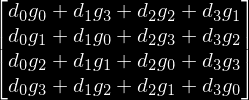

In [456]:
ssx = sy.MatMul(win1, bg1, win1, d1, evaluate=True)
ssx

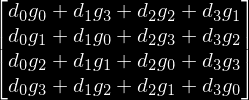

In [457]:
cc = Matrix(symmetrical_cyclic_convolution(np.array(d1).reshape(-1), np.array(g1).reshape(-1)))
cc

In [460]:
np.all(np.array(cc) == np.array(ssx))

True

In [461]:
import random
d1n = [random.randint(0, 2**3) for r in range(4)]
g1n = [random.randint(0, 2**3) for r in range(4)]

In [462]:
g1nsubs = {k: v for k, v in zip(g1.flat(), g1n)}
g1nsubs

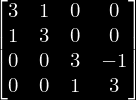

In [463]:
bg1subs = bg1.subs(g1nsubs)
bg1subs

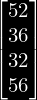

In [464]:
cc_out = sy.Matrix(symmetrical_cyclic_convolution(d1n, g1n))
cc_out

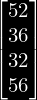

In [465]:
fcc_out = win1 * bg1subs * win1 * Matrix(d1n)
fcc_out

In [466]:
np.all(np.array(cc_out) == np.array(fcc_out))

True

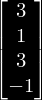

In [467]:
h1n = bg1t.subs(g1nsubs)
h1n

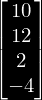

In [468]:
t1n =  win1 * Matrix(d1n)
t1n

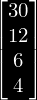

In [469]:
m1n = sy.hadamard_product(h1n, t1n)
m1n

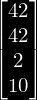

In [470]:
n1n = sh1 * m1n
n1n

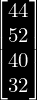

In [471]:
s1n = win1 * n1n
s1n

In [472]:
np.all(np.array(sorted(cc_out)) == np.array(sorted(s1n)))

False

In [473]:
(sorted(cc_out), sorted(s1n))